# AKI Prediction with Trajectory Modeling

## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import sys
import duckdb
from traj_ps.backends.bayes import BayesianTrajPS, BayesConfig
from traj_ps.backends.bayes.classify import pos_flags_from_traj, flags_from_traj
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, classification_report, confusion_matrix
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Import shared notebook utilities
sys.path.insert(0, os.path.abspath('.'))
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats, 
    plot_roc_pr_curves, print_statistical_comparisons, train_repeated_cv
)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print("✓ Shared utilities loaded")

✓ Imports successful
✓ Shared utilities loaded


## LOAD

In [2]:
# Connect to MIMIC-III DuckDB
db_path = '../../data/mimic/mimiciii.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to MIMIC-III database: {db_path}")

✓ Connected to MIMIC-III database: ../../data/mimic/mimiciii.duckdb


In [3]:
# Check available tables
tables = conn.execute("SHOW TABLES").fetchdf()
print(f"\nAvailable tables ({len(tables)}):")
print(tables['name'].tolist())


Available tables (26):
['ADMISSIONS', 'CALLOUT', 'CAREGIVERS', 'CHARTEVENTS', 'CPTEVENTS', 'DATETIMEEVENTS', 'DIAGNOSES_ICD', 'DRGCODES', 'D_CPT', 'D_ICD_DIAGNOSES', 'D_ICD_PROCEDURES', 'D_ITEMS', 'D_LABITEMS', 'ICUSTAYS', 'INPUTEVENTS_CV', 'INPUTEVENTS_MV', 'LABEVENTS', 'MICROBIOLOGYEVENTS', 'NOTEEVENTS', 'OUTPUTEVENTS', 'PATIENTS', 'PRESCRIPTIONS', 'PROCEDUREEVENTS_MV', 'PROCEDURES_ICD', 'SERVICES', 'TRANSFERS']


In [4]:
#  Load ICU stays with basic info
hadm_query = """
SELECT 
    i.subject_id::INTEGER AS subject_id,
    i.hadm_id::INTEGER AS hadm_id,
    a.admittime::TIMESTAMP as admittime,      -- Hospital admission time
    a.dischtime::TIMESTAMP as dischtime,      -- Hospital discharge time
    i.intime::TIMESTAMP as intime,         -- ICU admission time
    i.outtime::TIMESTAMP as outtime,        -- ICU discharge time
    CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) as los_days,  -- Hospital LOS
    p.gender,
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) as age,
    a.hospital_expire_flag::INT as hospital_expire_flag,
    a.discharge_location
FROM icustays i
INNER JOIN patients p ON i.subject_id = p.subject_id
INNER JOIN admissions a ON i.hadm_id = a.hadm_id
WHERE 
    -- Filter adults
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) BETWEEN 18 AND 90
    -- Minimum hospital stay
    AND CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) >= 2.0
"""

hadm_df = conn.execute(hadm_query).fetchdf()
hadm_df.columns = hadm_df.columns.str.lower()
print(f"\n✓ Loaded {len(hadm_df):,} hospital admissions")
print(f"  Unique patients: {hadm_df['subject_id'].nunique():,}")
print(f"  Mean hospital LOS: {hadm_df['los_days'].mean():.1f} days")
print(f"  Mortality: {hadm_df['hospital_expire_flag'].mean():.1%}")


✓ Loaded 48,094 hospital admissions
  Unique patients: 34,671
  Mean hospital LOS: 12.0 days
  Mortality: 10.3%


In [ ]:
hadm_subset = hadm_df.sort_values('admittime').drop_duplicates(subset=['subject_id'])['hadm_id'].sample(5000, random_state=920).tolist()
hadm_ids_str =  ",".join(map(str, hadm_subset))

In [6]:
# Load urine output (secondary marker for AKI)
urine_query = """
SELECT 
    oe.subject_id::INTEGER AS subject_id,
    oe.hadm_id::INTEGER AS hadm_id,
    oe.charttime::TIMESTAMP AS charttime,
    EXTRACT(EPOCH FROM (oe.charttime::TIMESTAMP - a.admittime::TIMESTAMP)) / 86400.0 as time_days,
    CAST(oe.value AS REAL) as urine_output
FROM outputevents oe
INNER JOIN icustays i 
    ON oe.subject_id = i.subject_id 
    AND oe.hadm_id = i.hadm_id
INNER JOIN admissions a ON i.hadm_id = a.hadm_id
    AND oe.charttime::timestamp BETWEEN a.admittime::timestamp AND a.dischtime::timestamp
WHERE 
    oe.itemid IN (40055, 43175, 40069, 40094, 40715, 40473, 40085, 40057, 40056, 40405, 40428, 40086, 40096, 40651)  -- Urine output
    AND oe.value::REAL IS NOT NULL
    AND oe.value::REAL >= 0
    AND oe.value::REAL < 5000  -- Remove outliers
    AND oe.hadm_id::INTEGER IN {hadm_ids}
ORDER BY oe.subject_id, oe.charttime
"""

urine_df = conn.execute(
    urine_query.format(hadm_ids=hadm_subset)
).fetchdf()
urine_df.columns = urine_df.columns.str.lower()

print(f"\n✓ Loaded {len(urine_df):,} urine output measurements")
print(f"  Hospital admissions with urine: {urine_df['hadm_id'].nunique():,}")


✓ Loaded 279,586 urine output measurements
  Hospital admissions with urine: 2,851


In [7]:
# Load valid ranges from metadata
vital_meta = pd.read_csv('../../data/mimic/vital_metadata.csv')
labs_meta = pd.read_csv('../../data/mimic/labs_metadata.csv')

print("✓ Loaded metadata for value range validation")
print(f"   Vitals: {len(vital_meta)} item IDs")
print(f"   Labs: {len(labs_meta)} item IDs")

✓ Loaded metadata for value range validation
   Vitals: 43 item IDs
   Labs: 27 item IDs


In [8]:
vital_items = vital_meta['itemid'].to_list()
lab_items = labs_meta['itemid'].to_list()

In [9]:
vitals_query = """
SELECT chartevents.subject_id::INTEGER AS subject_id
    , chartevents.hadm_id::INTEGER AS hadm_id
    , chartevents.charttime::TIMESTAMP AS charttime
    , chartevents.itemid::INTEGER AS itemid
    , chartevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
        FROM chartevents
                 INNER JOIN admissions
                            ON chartevents.subject_id = admissions.subject_id
                                AND chartevents.hadm_id = admissions.hadm_id
                                AND chartevents.charttime::TIMESTAMP between
                                   (admissions.admittime::TIMESTAMP)
                                   AND (admissions.dischtime::TIMESTAMP)
                                AND itemid::INTEGER in {itemids}
                                AND chartevents.hadm_id::INTEGER in {hadm_ids}
      -- exclude rows marked as error
      AND chartevents.error::INTEGER IS DISTINCT FROM 1 
"""

vitals_df = conn.execute(vitals_query.format(itemids=vital_items, hadm_ids=hadm_subset)).fetchdf()
vitals_df.columns = vitals_df.columns.str.lower()
print(f"✓ Loaded vitals for {vitals_df['hadm_id'].nunique():,} hospital admissions")

✓ Loaded vitals for 4,949 hospital admissions


In [10]:
labs_query = """
SELECT labevents.subject_id::INTEGER AS subject_id
      , labevents.hadm_id::INTEGER AS hadm_id
      , labevents.charttime::TIMESTAMP AS charttime
      , labevents.itemid::INTEGER AS itemid
      , labevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
FROM labevents
          INNER JOIN admissions
                    ON labevents.subject_id = admissions.subject_id
                        AND labevents.hadm_id = admissions.hadm_id
                        AND labevents.charttime::TIMESTAMP between
                            (admissions.admittime::TIMESTAMP)
                            AND (admissions.dischtime::TIMESTAMP)
                        AND itemid::INTEGER IN {itemids}
                        AND labevents.hadm_id::INTEGER IN {hadm_ids}
"""

labs_df = conn.execute(labs_query.format(itemids=lab_items, hadm_ids=hadm_subset)).fetchdf()
labs_df.columns = labs_df.columns.str.lower()
print(f"✓ Loaded labs for {labs_df['hadm_id'].nunique():,} hospital admissions")

✓ Loaded labs for 4,946 hospital admissions


In [11]:
meds_dynamic_query = """
WITH daily_meds AS (
    -- MetaVision
    SELECT 
        i.hadm_id::INTEGER AS hadm_id,
        FLOOR(EXTRACT(EPOCH FROM (ie.starttime::timestamp - a.admittime::timestamp)) / 86400.0) as time_day,
        MAX(CASE WHEN ie.itemid IN (30047, 30120, 221906, 221289, 30044, 30119, 30309) 
            THEN 1 ELSE 0 END) as vasopressor_current,
        MAX(CASE WHEN ie.itemid IN (30123, 30308, 221794, 30009, 41430) 
            THEN 1 ELSE 0 END) as diuretic_current
    FROM inputevents_mv ie
    INNER JOIN icustays i ON ie.hadm_id = i.hadm_id
    INNER JOIN admissions a ON i.hadm_id = a.hadm_id
    WHERE 
        ie.starttime::timestamp BETWEEN a.admittime::timestamp AND a.dischtime::timestamp
        AND i.hadm_id::INTEGER IN {hadm_ids}
    GROUP BY i.hadm_id, time_day
    
    UNION
    
    -- CareVue
    SELECT 
        i.hadm_id,
        FLOOR(EXTRACT(EPOCH FROM (ie.charttime::timestamp - a.admittime::timestamp)) / 86400.0) as time_day,
        MAX(CASE WHEN ie.itemid IN (30047, 30120, 221906, 221289, 30044, 30119, 30309) 
            THEN 1 ELSE 0 END) as vasopressor_current,
        MAX(CASE WHEN ie.itemid IN (30123, 30308, 221794, 30009, 41430) 
            THEN 1 ELSE 0 END) as diuretic_current
    FROM inputevents_cv ie
    INNER JOIN icustays i ON ie.hadm_id = i.hadm_id
    INNER JOIN admissions a ON i.hadm_id = a.hadm_id
    WHERE 
        ie.charttime::timestamp BETWEEN a.admittime::timestamp AND a.dischtime::timestamp
        AND i.hadm_id::INTEGER IN {hadm_ids}
    GROUP BY i.hadm_id, time_day
)
SELECT 
    hadm_id,
    time_day,
    MAX(vasopressor_current) as vasopressor_current,
    MAX(diuretic_current) as diuretic_current
FROM daily_meds
GROUP BY hadm_id, time_day
"""

meds_dynamic_df = conn.execute(meds_dynamic_query.format(hadm_ids=hadm_subset)).fetchdf()
meds_dynamic_df.columns = meds_dynamic_df.columns.str.lower()
print(f"✓ Loaded dynamic medications: {len(meds_dynamic_df):,} (hadm_id, day) pairs")

✓ Loaded dynamic medications: 26,267 (hadm_id, day) pairs


In [12]:
comorbid_query = """
SELECT DISTINCT
    i.hadm_id::INTEGER AS hadm_id,
    MAX(CASE WHEN d.icd9_code LIKE '250%' THEN 1 ELSE 0 END) as diabetes,
    MAX(CASE WHEN d.icd9_code LIKE '401%' OR d.icd9_code LIKE '402%' THEN 1 ELSE 0 END) as hypertension,
    MAX(CASE WHEN d.icd9_code LIKE '428%' THEN 1 ELSE 0 END) as heart_failure,
    MAX(CASE WHEN d.icd9_code LIKE '585%' THEN 1 ELSE 0 END) as ckd
FROM diagnoses_icd d
INNER JOIN icustays i ON d.subject_id = i.subject_id AND d.hadm_id = i.hadm_id
WHERE i.hadm_id::INTEGER IN {hadm_ids}
GROUP BY i.hadm_id
"""

comorbid_df = conn.execute(comorbid_query.format(hadm_ids=hadm_subset)).fetchdf()
comorbid_df.columns = comorbid_df.columns.str.lower()
print(f"✓ Loaded comorbidities for {len(comorbid_df):,} hospital admissions")

✓ Loaded comorbidities for 5,000 hospital admissions


# PREPROCESS

In [13]:
# extract creatinine
creat_meta = labs_meta[labs_meta['feature name'] == 'CREATININE']

creat_df = labs_df.merge(creat_meta, on='itemid', how='inner')
creat_df = creat_df[creat_df['valuenum'].between(creat_df['min'], creat_df['max'], inclusive='both')]

# first day creatinine
firstd_creat = creat_df[creat_df['charttime'] <= creat_df['admittime'] + pd.Timedelta(days=1)]
baseline_creat_df = firstd_creat.sort_values('charttime').pivot_table(index='hadm_id',
                                                                       columns='feature name',
                                                                         values='valuenum',
                                                                           aggfunc='first').reset_index().rename(columns={'CREATININE': 'baseline_creatinine'})

In [14]:
hadm_df['hadm_id'] = hadm_df['hadm_id'].astype(int)

In [15]:
# Merge baseline creatinine with hospital admissions (take only subjects with baseline creatinine)
hadm_enriched = hadm_df.merge(
    baseline_creat_df,
    on='hadm_id',
    how='inner'
)


print(f"\n Baseline Creatinine:")
print(f"   Missing: {hadm_enriched['baseline_creatinine'].isna().mean():.2%}")
print(f"   Mean: {hadm_enriched['baseline_creatinine'].mean():.2f} mg/dL")
print(f"   Median: {hadm_enriched['baseline_creatinine'].median():.2f} mg/dL")


 Baseline Creatinine:
   Missing: 0.00%
   Mean: 1.28 mg/dL
   Median: 0.90 mg/dL


In [16]:
# Filter patients with sufficient creatinine measurements
creat_counts = creat_df.groupby('hadm_id').size()
valid_hadm_ids = creat_counts[creat_counts >= 5].index

creatinine_filtered = creat_df[creat_df['hadm_id'].isin(valid_hadm_ids)]
hadm_final = hadm_enriched[hadm_enriched['hadm_id'].isin(valid_hadm_ids)]
print(f"\n Filtering:")
print(f"   Hospital admissions with ≥5 creatinine measurements: {len(hadm_final):,}")


 Filtering:
   Hospital admissions with ≥5 creatinine measurements: 4,061


In [17]:
# Aggregate vitals and labs using shared utility
vitals_labs_pivot = aggregate_vitals_labs(
    vitals_df=vitals_df,
    labs_df=labs_df,
    vital_meta=vital_meta,
    labs_meta=labs_meta
)

In [18]:
vitals_labs_pivot.columns

Index(['ALBUMIN_min', 'ANION GAP_min', 'BICARBONATE_min', 'BILIRUBIN_min',
       'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min',
       'GLUCOSE_min', 'Glucose_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min',
       'HeartRate_min', 'INR_min', 'LACTATE_min', 'MAGNESIUM_min',
       'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min',
       'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min', 'SpO2_min',
       'SysBP_min', 'TempC_min', 'WBC_min', 'Weight_min', 'ALBUMIN_max',
       'ANION GAP_max', 'BICARBONATE_max', 'BILIRUBIN_max', 'BUN_max',
       'CHLORIDE_max', 'CREATININE_max', 'DiasBP_max', 'GLUCOSE_max',
       'Glucose_max', 'HEMATOCRIT_max', 'HEMOGLOBIN_max', 'HeartRate_max',
       'INR_max', 'LACTATE_max', 'MAGNESIUM_max', 'MeanBP_max',
       'PHOSPHATE_max', 'PLATELET_max', 'POTASSIUM_max', 'PT_max', 'PTT_max',
       'RespRate_max', 'SODIUM_max', 'SpO2_max', 'SysBP_max', 'TempC_max',
       'WBC_max', 'Weight_max', 'ALBUMIN_mean', 'ANION GAP_mean',
      

In [19]:
# ffill imputation
vitals_labs_imputed = vitals_labs_pivot.groupby('hadm_id').ffill()

# Special handling for Weight - use both forward and backward fill
vitals_labs_imputed['Weight_mean'] = vitals_labs_imputed.groupby('hadm_id')['Weight_mean'].bfill()

In [20]:
# Apply shared utility for post-imputation cleanup
vitals_labs_imputed, drop_cols = drop_high_missing_columns(vitals_labs_imputed, threshold=0.2)



In [21]:
drop_cols

['ALBUMIN_min',
 'BILIRUBIN_min',
 'LACTATE_min',
 'Weight_min',
 'ALBUMIN_max',
 'BILIRUBIN_max',
 'LACTATE_max',
 'Weight_max',
 'ALBUMIN_mean',
 'BILIRUBIN_mean',
 'LACTATE_mean']

In [24]:
vitals_labs_imputed = vitals_labs_imputed.reset_index().drop(columns=['admittime'])

hadm_final['admittime'] = pd.to_datetime(hadm_final['admittime'])

meds_dynamic_df['hadm_id'] = meds_dynamic_df['hadm_id'].astype(int)
meds_dynamic_df['time_day'] = meds_dynamic_df['time_day'].astype(int)

In [32]:
hadm_final['hadm_id'] = hadm_final['hadm_id'].astype(np.int32)

In [33]:
hadm_final.dtypes

subject_id                       int32
hadm_id                          int32
admittime               datetime64[us]
dischtime               datetime64[us]
intime                  datetime64[us]
outtime                 datetime64[us]
los_days                       float32
gender                          object
age                              int32
hospital_expire_flag             int32
discharge_location              object
baseline_creatinine            float64
dtype: object

In [34]:
hadm_final = hadm_final.merge(vitals_labs_imputed, on=['hadm_id'], how='inner')
hadm_final['time_day'] = (hadm_final['charttime'] - hadm_final['admittime']).dt.days

In [36]:
meds_dynamic_df['hadm_id'] = meds_dynamic_df['hadm_id'].astype(np.int32)

In [37]:
hadm_final = hadm_final.merge(meds_dynamic_df, on=['hadm_id', 'time_day'], how='left')

In [38]:
binary_cols = ['vasopressor_current', 'diuretic_current']
hadm_final[binary_cols] = hadm_final[binary_cols].fillna(0)

In [39]:
creatinine_filtered['eod_flag'] = 0
creatinine_filtered.loc[creatinine_filtered.groupby(['hadm_id', pd.Grouper(key='charttime', freq='D')])['charttime'].idxmax(),
                         'eod_flag'] = 1

In [40]:
creatinine_filtered['time_days'] = (creatinine_filtered['charttime'] - creatinine_filtered['admittime']).dt.total_seconds() / (24 * 3600)
creatinine_filtered['time_day'] = creatinine_filtered['time_days'].apply(np.floor)

In [41]:
print(f"\n✓ Added end-of-day flags:")
print(f"   Total measurements: {len(creatinine_filtered):,}")
print(f"   Last-of-day measurements: {creatinine_filtered['eod_flag'].sum():,}")
print(f"   Percentage: {100*creatinine_filtered['eod_flag'].mean():.1f}%")

# Preview
print(f"\nSample patient (hadm_id={creatinine_filtered['hadm_id'].iloc[0]}):")
sample = creatinine_filtered[creatinine_filtered['hadm_id'] == creatinine_filtered['hadm_id'].iloc[0]].head(10)
print(sample[['hadm_id', 'charttime', 'time_days', 'time_day', 'valuenum', 'eod_flag']].to_string(index=False))


✓ Added end-of-day flags:
   Total measurements: 56,896
   Last-of-day measurements: 44,212
   Percentage: 77.7%

Sample patient (hadm_id=135491):
 hadm_id           charttime  time_days  time_day  valuenum  eod_flag
  135491 2193-12-29 03:44:00  23.853472      23.0       0.8         1
  135491 2193-12-30 06:50:00  24.982639      24.0       0.9         1
  135491 2193-12-06 06:35:00   0.972222       0.0       1.4         1
  135491 2193-12-07 01:45:00   1.770833       1.0       1.0         1
  135491 2193-12-09 03:35:00   3.847222       3.0       1.0         1
  135491 2193-12-05 15:31:00   0.344444       0.0       0.8         1
  135491 2193-12-08 03:06:00   2.827083       2.0       1.0         1
  135491 2193-12-13 13:34:00   8.263194       8.0       0.9         1
  135491 2193-12-14 03:48:00   8.856250       8.0       1.0         1
  135491 2193-12-10 04:26:00   4.882639       4.0       0.9         1


In [42]:
# creatinine time series and merged with baseline
creatinine_ts = creatinine_filtered[['hadm_id', 'subject_id', 'time_days', 'time_day', 'valuenum', 'eod_flag']].merge(
    hadm_final[['hadm_id', 'baseline_creatinine', 'age', 'gender', 'hospital_expire_flag']].drop_duplicates(),
    on='hadm_id',
    how='left'
).rename(columns={'valuenum': 'creatinine'})

creatinine_ts['creat_fold_change'] = creatinine_ts['creatinine'] / creatinine_ts['baseline_creatinine']

creatinine_ts = creatinine_ts[['subject_id', 'hadm_id', 'time_days', 'time_day','creatinine',
       'baseline_creatinine', 'age', 'gender', 'hospital_expire_flag', 'creat_fold_change', 'eod_flag']]


print(f"\n Feature Engineering:")
print(f"   Mean fold-change: {creatinine_ts['creat_fold_change'].mean():.2f}")


 Feature Engineering:
   Mean fold-change: 1.07


In [44]:
creatinine_ts['time_days']

0        23.853472
1        24.982639
2        10.225694
3        11.215972
4        12.246528
           ...    
56891     1.381250
56892     5.095833
56893     6.076389
56894     7.067361
56895     0.147917
Name: time_days, Length: 56896, dtype: float64

In [ ]:
# Save
os.makedirs('../../results/mimic', exist_ok=True)
creatinine_ts.to_csv('../../results/mimic/creatinine_timeseries.csv', index=False)
hadm_final.to_csv('../../results/mimic/hadm_cohort.csv', index=False)

print(f"\n✓ Saved preprocessed data")


✓ Saved preprocessed data


In [ ]:
# read the saved data
creatinine_ts = pd.read_csv('../../results/mimic/creatinine_timeseries.csv')
hadm_final = pd.read_csv('../../results/mimic/hadm_cohort.csv')
print(creatinine_ts.columns)
print(hadm_final.columns)
print("✓ Loaded saved data")

Index(['subject_id', 'hadm_id', 'time_days', 'time_day', 'creatinine',
       'baseline_creatinine', 'age', 'gender', 'hospital_expire_flag',
       'creat_fold_change', 'eod_flag'],
      dtype='object')
Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'intime', 'outtime',
       'los_days', 'gender', 'age', 'hospital_expire_flag',
       'discharge_location', 'baseline_creatinine', 'index', 'charttime',
       'ANION GAP_min', 'BICARBONATE_min', 'BUN_min', 'CHLORIDE_min',
       'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min', 'Glucose_min',
       'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min', 'INR_min',
       'MAGNESIUM_min', 'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min',
       'POTASSIUM_min', 'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min',
       'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min', 'ANION GAP_max',
       'BICARBONATE_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOG

In [6]:
hadm_subset = hadm_final['hadm_id'].unique().tolist()

## TRAJ PROBS

In [43]:
# creatinine trajectories modeling is done in aki_trajs.py
# read saved data
trajectory_probs_full = pd.read_csv('../../results/mimic/aki/aki_trajectory_probs_bayes.csv')
print(trajectory_probs_full.columns)
print("✓ Loaded saved data")

Index(['subject_id', 'hadm_id', 'time_days', 'time_day', 'creatinine',
       'baseline_creatinine', 'creat_fold_change', 'prob_stable',
       'prob_gradual_increase', 'prob_rapid_increase', 'age', 'gender',
       'hospital_expire_flag'],
      dtype='object')
✓ Loaded saved data


In [47]:
creatinine_ts.dtypes

subject_id                int32
hadm_id                   int32
time_days               float64
time_day                float64
creatinine              float64
baseline_creatinine     float64
age                     float64
gender                   object
hospital_expire_flag    float64
creat_fold_change       float64
eod_flag                  int64
dtype: object

In [45]:
trajectory_probs_full['hadm_id'] = trajectory_probs_full['hadm_id'].astype(np.int32)

  stable: plotted 1, skipped 49 (insufficient data)
  gradual_increase: plotted 4, skipped 46 (insufficient data)
  rapid_increase: plotted 5, skipped 45 (insufficient data)

✓ Saved trajectory plots (7-day lookback windows)


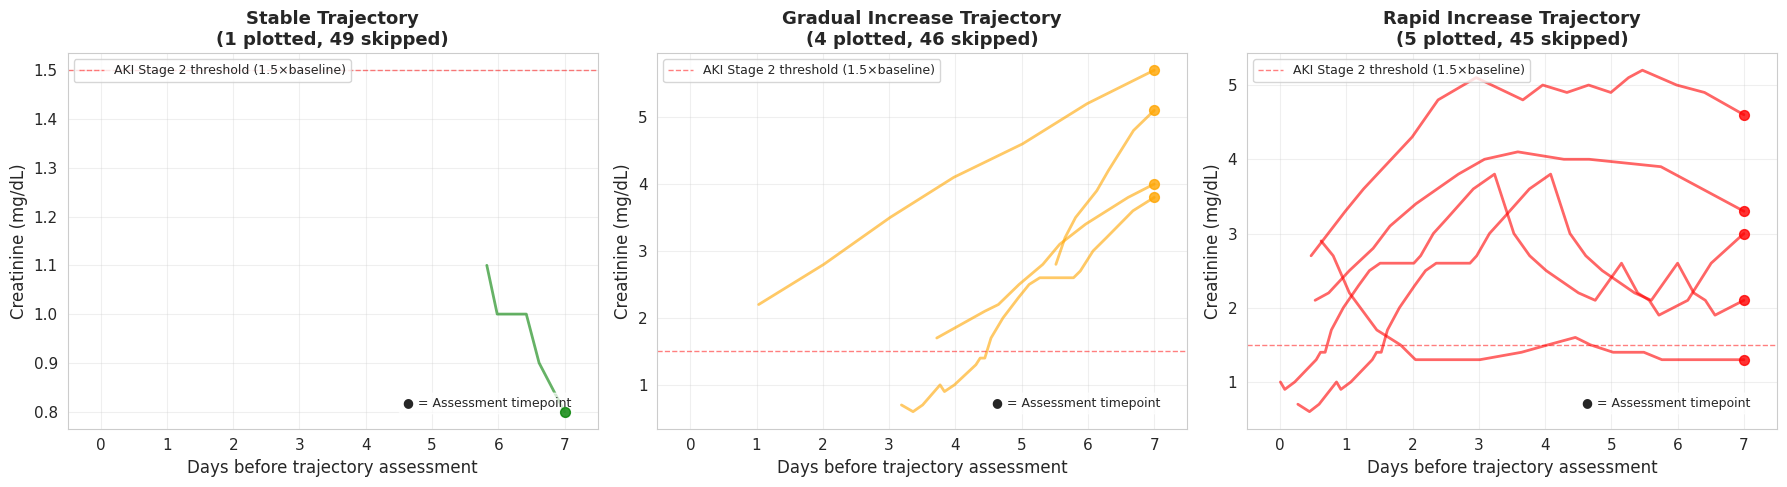


📊 Trajectory Window Summary:

   Stable:
      Timepoints with prob>0.6: 24,864
      Unique patients: 3,185
      Mean probability: 0.984

   Gradual Increase:
      Timepoints with prob>0.6: 158
      Unique patients: 83
      Mean probability: 0.882

   Rapid Increase:
      Timepoints with prob>0.6: 2,581
      Unique patients: 522
      Mean probability: 0.883


In [46]:
# Visualize trajectories with 7-day lookback window
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
traj_types = ['stable', 'gradual_increase', 'rapid_increase']
colors = ['green', 'orange', 'red']

LOOKBACK_DAYS = 7  # Window size for trajectory visualization
MIN_POINTS = 2     # Minimum data points required (reduced from 3)
MAX_PLOTS = 15     # Maximum trajectories to plot per type (increased from 10)

for idx, (traj, color) in enumerate(zip(traj_types, colors)):
    traj_col = f'prob_{traj}'
    
    # Find timepoints with high probability for this trajectory type
    high_prob_timepoints = trajectory_probs_full[trajectory_probs_full[traj_col] > 0.6].copy()  # Lowered threshold from 0.7
    
    if len(high_prob_timepoints) == 0:
        print(f"⚠️  No high-probability timepoints found for {traj}")
        continue
    
    # Sort by probability - allow multiple timepoints per patient to get more examples
    high_prob_timepoints = high_prob_timepoints.sort_values(traj_col, ascending=False)
    # Don't restrict to first per patient - take up to 50 highest probability timepoints
    selected_timepoints = high_prob_timepoints.head(50).reset_index(drop=True)
    
    ax = axes[idx]
    n_plotted = 0
    n_skipped = 0
    
    for _, row in selected_timepoints.iterrows():
        hadm_id = row['hadm_id']
        prob_time = row['time_days']
        
        # Get creatinine data for this patient
        patient_data = creatinine_ts[creatinine_ts['hadm_id'] == hadm_id].sort_values('time_days')
        
        if len(patient_data) == 0:
            n_skipped += 1
            continue
        
        # Filter to 7-day window BEFORE the trajectory probability timepoint
        window_start = prob_time - LOOKBACK_DAYS
        window_end = prob_time
        
        window_data = patient_data[
            patient_data['time_days'].between(window_start, window_end, inclusive='both')
        ]
        
        # Only plot if we have sufficient data in the window
        if len(window_data) >= MIN_POINTS:
            # Normalize time to start from 0 (relative to window start)
            relative_time = window_data['time_days'] - window_start
            
            ax.plot(relative_time, window_data['creatinine'],
                    alpha=0.6, linewidth=2, color=color)
            
            # Mark the endpoint (where trajectory probability was computed)
            ax.scatter(relative_time.iloc[-1], window_data['creatinine'].iloc[-1],
                      color=color, s=50, alpha=0.8, zorder=5)
            
            n_plotted += 1
            
            if n_plotted >= MAX_PLOTS:
                break
        else:
            n_skipped += 1
    
    ax.set_xlabel(f'Days before trajectory assessment', fontsize=12)
    ax.set_ylabel('Creatinine (mg/dL)', fontsize=12)
    ax.set_title(f'{traj.replace("_", " ").title()} Trajectory\n'
                 f'({n_plotted} plotted, {n_skipped} skipped)',
                 fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.axhline(1.5, color='red', linestyle='--', linewidth=1, alpha=0.5, 
               label='AKI Stage 2 threshold (1.5×baseline)')
    ax.set_xlim(-0.5, LOOKBACK_DAYS + 0.5)
    ax.legend(fontsize=9, loc='upper left')
    
    # Add annotation for endpoint
    ax.text(0.95, 0.05, '● = Assessment timepoint', 
            transform=ax.transAxes, fontsize=9,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    print(f"  {traj}: plotted {n_plotted}, skipped {n_skipped} (insufficient data)")

plt.tight_layout()
plt.savefig('../../results/mimic/aki/aki_trajectory_examples_bayes_windowed.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved trajectory plots (7-day lookback windows)")
plt.show()

# Print summary statistics
print(f"\n📊 Trajectory Window Summary:")
for traj in traj_types:
    traj_col = f'prob_{traj}'
    high_prob = trajectory_probs_full[trajectory_probs_full[traj_col] > 0.6]
    print(f"\n   {traj.replace('_', ' ').title()}:")
    print(f"      Timepoints with prob>0.6: {len(high_prob):,}")
    print(f"      Unique patients: {high_prob['hadm_id'].nunique():,}")
    if len(high_prob) > 0:
        print(f"      Mean probability: {high_prob[traj_col].mean():.3f}")

## DEFINE OUTCOME

In [30]:
# Load dialysis data with CORRECTED ICD-9 matching
dialysis_query = """
WITH dialysis_procedures AS (
    -- 1. Procedures (MetaVision)
    SELECT DISTINCT
        i.hadm_id::INT as hadm_id,
        MIN(EXTRACT(EPOCH FROM (pe.starttime::timestamp - a.admittime::timestamp)) / 86400) as dialysis_start_time,
        'procedureevents_mv' as source
    FROM procedureevents_mv pe
    INNER JOIN icustays i ON pe.hadm_id = i.hadm_id
    INNER JOIN admissions a ON i.hadm_id = a.hadm_id
    WHERE 
        pe.itemid IN (225805, 225809, 225802, 225803, 225441)
        AND pe.starttime::timestamp BETWEEN a.admittime::timestamp AND a.dischtime::timestamp
        AND i.hadm_id::INT IN {hadm_ids}
    GROUP BY i.hadm_id
    
    UNION
    
    -- 2. Input Events (dialysis solutions)
    SELECT DISTINCT
        i.hadm_id::INT as hadm_id,
        MIN(EXTRACT(EPOCH FROM (ie.starttime::timestamp - a.admittime::timestamp)) / 86400) as dialysis_start_time,
        'inputevents_mv' as source
    FROM inputevents_mv ie
    INNER JOIN icustays i ON ie.hadm_id = i.hadm_id
    INNER JOIN admissions a ON i.hadm_id = a.hadm_id
    WHERE 
        ie.itemid IN (227536, 227525)
        AND ie.starttime::timestamp BETWEEN a.admittime::timestamp AND a.dischtime::timestamp
        AND i.hadm_id::INT IN {hadm_ids}
    GROUP BY i.hadm_id
    
    UNION
    
    -- 3. Chart Events (dialysis documentation)
    SELECT DISTINCT
        i.hadm_id::INT as hadm_id,
        MIN(EXTRACT(EPOCH FROM (ce.charttime::timestamp - a.admittime::timestamp)) / 86400) as dialysis_start_time,
        'chartevents' as source
    FROM chartevents ce
    INNER JOIN icustays i ON ce.hadm_id = i.hadm_id
    INNER JOIN admissions a ON i.hadm_id = a.hadm_id
    WHERE 
        ce.itemid IN (226499, 224154, 225810, 225806, 225807, 225959)
        AND ce.charttime::timestamp BETWEEN a.admittime::timestamp AND a.dischtime::timestamp
        AND i.hadm_id::INT IN {hadm_ids}
    GROUP BY i.hadm_id
    
    UNION
    
    -- 4. ICD-9 Diagnosis Codes (FIXED WITH WILDCARDS)
    SELECT DISTINCT
        i.hadm_id::INT as hadm_id,
        0.0 as dialysis_start_time,
        'diagnoses_icd' as source
    FROM diagnoses_icd d
    INNER JOIN icustays i ON d.subject_id = i.subject_id AND d.hadm_id = i.hadm_id
    WHERE 
        (
            d.icd9_code LIKE '3995%'   OR  -- Hemodialysis (39.95)
            d.icd9_code LIKE '5498%'   OR  -- Peritoneal dialysis (54.98)
            d.icd9_code LIKE 'V451%'   OR  -- Renal dialysis status (V45.1, V45.11)
            d.icd9_code LIKE 'V5631%'  OR  -- Adequacy testing for dialysis (V56.31)
            d.icd9_code LIKE 'V560%'   OR  -- Extracorporeal dialysis (V56.0)
            d.icd9_code LIKE 'V561%'       -- Peritoneal dialysis fitting/adjustment (V56.1, V56.2)
        )
        AND i.hadm_id::INT IN {hadm_ids}
)
SELECT 
    hadm_id,
    MIN(dialysis_start_time) as dialysis_start_time,
    STRING_AGG(DISTINCT source, ', ' ORDER BY source) as sources
FROM dialysis_procedures
GROUP BY hadm_id
ORDER BY hadm_id
"""

try:
    dialysis_df = conn.execute(dialysis_query.format(hadm_ids=hadm_subset)).fetchdf()
    dialysis_df.columns = dialysis_df.columns.str.lower()
    print(f"✓ Loaded dialysis data: {len(dialysis_df)} patients")
    print(f"\n📊 Detection by source:")
    source_counts = dialysis_df['sources'].value_counts()
    for source, count in source_counts.items():
        print(f"   {source:60s}: {count:3d} patients")
    
    # Breakdown by primary source
    dialysis_df['primary_source'] = dialysis_df['sources'].str.split(',').str[0].str.strip()
    print(f"\n  Primary detection source:")
    for source in ['procedureevents_mv', 'chartevents', 'diagnoses_icd', 'inputevents_mv']:
        count = (dialysis_df['primary_source'] == source).sum()
        if count > 0:
            print(f"   {source:20s}: {count:3d} patients ({100*count/len(dialysis_df):.1f}%)")
    
except Exception as e:
    print(f"⚠️  Error loading dialysis data: {e}")
    import traceback
    traceback.print_exc()
    dialysis_df = pd.DataFrame(columns=['hadm_id', 'dialysis_start_time', 'sources'])

dialysis_df.columns = dialysis_df.columns.str.lower()

✓ Loaded dialysis data: 120 patients

📊 Detection by source:
   chartevents, inputevents_mv, procedureevents_mv             :  54 patients
   chartevents, procedureevents_mv                             :  18 patients
   chartevents, diagnoses_icd, procedureevents_mv              :  14 patients
   diagnoses_icd                                               :  11 patients
   diagnoses_icd, procedureevents_mv                           :   7 patients
   procedureevents_mv                                          :   6 patients
   chartevents, diagnoses_icd, inputevents_mv, procedureevents_mv:   5 patients
   chartevents                                                 :   3 patients
   chartevents, diagnoses_icd                                  :   2 patients

  Primary detection source:
   procedureevents_mv  :   6 patients (5.0%)
   chartevents         :  96 patients (80.0%)
   diagnoses_icd       :  18 patients (15.0%)


In [31]:
# Configuration
PREDICTION_GAP_DAYS = 1.0      # Don't predict events within 24h (too immediate for intervention)
PREDICTION_WINDOW_DAYS = 7.0   # Predict AKI Stage 3 within 7 days after gap

print(f"📋 Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days (exclusion period)")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days (prediction horizon)")
print(f"   Total:  {PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS} days lookahead")

aki_events = []
excluded_counts = {'already_aki': 0, 'no_future_data': 0, 'within_gap': 0}

for hadm_id, grp in trajectory_probs_full.groupby('hadm_id'):
    grp = grp.sort_values('time_day')
    baseline = grp['baseline_creatinine'].iloc[0]
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_creat = grp.iloc[i]['creatinine']
        
        # Skip if already in AKI Stage 3 (prevalent cases)
        if current_creat >= 3 * baseline or current_creat >= 4.0:
            excluded_counts['already_aki'] += 1
            continue
        
        # Define prediction window (with gap)
        prediction_start = current_time + PREDICTION_GAP_DAYS
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS
        
        future_window = grp[
            (grp['time_day'] >= prediction_start) & 
            (grp['time_day'] <= prediction_end)
        ]
        
        if len(future_window) == 0:
            excluded_counts['no_future_data'] += 1
            continue
        
        # Check AKI Stage 3 criteria in prediction window
        aki_stage3_creat = (
            (future_window['creatinine'] >= 3 * baseline).any() |
            ((future_window['creatinine'] >= 4.0) & 
             (future_window['creatinine'] - current_creat >= 0.5)).any()
        )
        
        # Check dialysis in prediction window
        dialysis_in_window = False
        if hadm_id in dialysis_df['hadm_id'].values:
            dialysis_time = dialysis_df[dialysis_df['hadm_id'] == hadm_id]['dialysis_start_time'].iloc[0]
            dialysis_in_window = (prediction_start <= dialysis_time <= prediction_end)
        
        # Combined outcome
        target_aki = int(aki_stage3_creat or dialysis_in_window)
        
        aki_events.append({
            'hadm_id': hadm_id,
            'time_day': current_time,
            'target_aki_stage3': target_aki,
            'current_creatinine': current_creat,
            'baseline_creatinine': baseline,
            'creat_fold_change': current_creat / baseline,
            'prediction_gap_days': PREDICTION_GAP_DAYS,
            'prediction_window_days': PREDICTION_WINDOW_DAYS
        })

aki_outcomes_df = pd.DataFrame(aki_events)

print(f"\n📊 Outcome Definition Summary:")
print(f"   Total prediction windows: {len(aki_outcomes_df):,}")
print(f"   Unique ICU stays: {aki_outcomes_df['hadm_id'].nunique():,}")
print(f"   Windows per stay: {aki_outcomes_df.groupby('hadm_id').size().mean():.1f}")

print(f"\n   Exclusions:")
print(f"      Already in AKI Stage 3: {excluded_counts['already_aki']:,}")
print(f"      No future data: {excluded_counts['no_future_data']:,}")

print(f"\n   AKI Stage 3 Events ({PREDICTION_GAP_DAYS}+{PREDICTION_WINDOW_DAYS} days):")
print(f"      Total events: {aki_outcomes_df['target_aki_stage3'].sum():,}")
print(f"      Event rate: {100*aki_outcomes_df['target_aki_stage3'].mean():.1f}%")
print(f"      Expected: ~2-5% for 7-day prediction window in ICU")

# Validation checks
print(f"\n🔍 Validation:")
if aki_outcomes_df['target_aki_stage3'].mean() < 0.01:
    print(f"   ⚠️  Event rate very low (<1%) - consider:")
    print(f"      - Shorter prediction window (3-5 days)")
    print(f"      - Smaller prediction gap (0.5 days)")
elif aki_outcomes_df['target_aki_stage3'].mean() > 0.15:
    print(f"   ⚠️  Event rate high (>15%) - consider:")
    print(f"      - Longer prediction window (10-14 days)")
    print(f"      - Larger prediction gap (2 days)")
else:
    print(f"   ✓ Event rate reasonable for predictive modeling")

📋 Prediction Configuration:
   Gap:    1.0 days (exclusion period)
   Window: 7.0 days (prediction horizon)
   Total:  8.0 days lookahead

📊 Outcome Definition Summary:
   Total prediction windows: 23,179
   Unique ICU stays: 2,797
   Windows per stay: 8.3

   Exclusions:
      Already in AKI Stage 3: 2,274
      No future data: 3,166

   AKI Stage 3 Events (1.0+7.0 days):
      Total events: 999
      Event rate: 4.3%
      Expected: ~2-5% for 7-day prediction window in ICU

🔍 Validation:
   ✓ Event rate reasonable for predictive modeling


In [15]:
hadm_final.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'intime', 'outtime',
       'los_days', 'gender', 'age', 'hospital_expire_flag',
       'discharge_location', 'baseline_creatinine', 'index', 'charttime',
       'ANION GAP_min', 'BICARBONATE_min', 'BUN_min', 'CHLORIDE_min',
       'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min', 'Glucose_min',
       'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min', 'INR_min',
       'MAGNESIUM_min', 'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min',
       'POTASSIUM_min', 'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min',
       'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min', 'ANION GAP_max',
       'BICARBONATE_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'MAGNESIUM_max',
       'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max', 'POTASSIUM_max',
       'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_max', 'SpO2_max',
       

In [16]:
aki_outcomes_df.head()

,hadm_id,time_day,target_aki_stage3,current_creatinine,baseline_creatinine,creat_fold_change,prediction_gap_days,prediction_window_days
0,100012,3.0,0,0.8,1.0,0.8,1.0,7.0
1,100012,4.0,0,0.7,1.0,0.7,1.0,7.0
2,100012,5.0,0,0.7,1.0,0.7,1.0,7.0
3,100012,6.0,0,0.9,1.0,0.9,1.0,7.0
4,100012,7.0,0,1.0,1.0,1.0,1.0,7.0


In [32]:
# Merge trajectory probabilities with demographics
prediction_dataset = aki_outcomes_df.merge(
    trajectory_probs_full[[
        'hadm_id', 'time_day', 
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
    ]],
    on=['hadm_id', 'time_day'],
    how='left'
)

# Merge STATIC first-day features
static_features = [
    'hadm_id',
    'age', 'gender', 'hospital_expire_flag',  # Demographics
    ]

# Get unique rows from hadm_final (remove time_day duplicates for static merge)
hadm_static = hadm_final[static_features].drop_duplicates(subset='hadm_id')

prediction_dataset = prediction_dataset.merge(
    hadm_static,
    on='hadm_id',
    how='left'
)

# Merge DYNAMIC current features (matched by hadm_id + time_day)
dynamic_features = [
    'hadm_id', 'time_day',
     'ANION GAP_min', 'BICARBONATE_min', 'BUN_min', 'CHLORIDE_min',
       'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min', 'Glucose_min',
       'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min', 'INR_min',
       'MAGNESIUM_min', 'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min',
       'POTASSIUM_min', 'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min',
       'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min', 'ANION GAP_max',
       'BICARBONATE_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'MAGNESIUM_max',
       'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max', 'POTASSIUM_max',
       'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_max', 'SpO2_max',
       'SysBP_max', 'TempC_max', 'WBC_max', 'ANION GAP_mean',
       'BICARBONATE_mean', 'BUN_mean', 'CHLORIDE_mean', 'CREATININE_mean',
       'DiasBP_mean', 'GLUCOSE_mean', 'Glucose_mean', 'HEMATOCRIT_mean',
       'HEMOGLOBIN_mean', 'HeartRate_mean', 'INR_mean', 'MAGNESIUM_mean',
       'MeanBP_mean', 'PHOSPHATE_mean', 'PLATELET_mean', 'POTASSIUM_mean',
       'PT_mean', 'PTT_mean', 'RespRate_mean', 'SODIUM_mean', 'SpO2_mean',
       'SysBP_mean', 'TempC_mean', 'WBC_mean', 'Weight_mean', 'vasopressor_current', 'diuretic_current'
]

# Get unique dynamic rows
hadm_dynamic = hadm_final[dynamic_features].drop_duplicates(subset=['hadm_id', 'time_day'])

prediction_dataset = prediction_dataset.merge(
    hadm_dynamic,
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add derived trajectory feature
prediction_dataset['prob_worsening'] = (
    prediction_dataset['prob_gradual_increase'] + 
    prediction_dataset['prob_rapid_increase']
)

# Add creatinine-derived features
prediction_dataset['creat_above_normal'] = (prediction_dataset['CREATININE_mean'] > 1.2).astype(int)

print(f"\n📋 Final Prediction Dataset:")
print(f"   Rows: {len(prediction_dataset):,}")
print(f"   Columns: {len(prediction_dataset.columns)}")
print(f"   Unique admissions: {prediction_dataset['hadm_id'].nunique():,}")

# Save
prediction_dataset.to_csv('../../results/mimic/aki_prediction_dataset.csv', index=False)
print(f"\n✓ Saved: results/mimic/aki_prediction_dataset.csv")


📋 Final Prediction Dataset:
   Rows: 23,179
   Columns: 94
   Unique admissions: 2,797

✓ Saved: results/mimic/aki_prediction_dataset.csv


In [ ]:
prediction_dataset = pd.read_csv('../../results/mimic/aki_prediction_dataset.csv')
print(f"✓ Loaded: results/mimic/aki_prediction_dataset.csv")

✓ Loaded: results/mimic/aki_prediction_dataset.csv


In [33]:
prediction_dataset.isna().mean()[prediction_dataset.isna().mean() > 0].sort_values(ascending=False)

TempC_mean              0.870961
TempC_max               0.870961
TempC_min               0.870961
Glucose_max             0.870874
Glucose_min             0.870874
                          ...   
age                     0.860218
gender                  0.860218
hospital_expire_flag    0.860218
baseline_creatinine     0.033306
creat_fold_change       0.033306
Length: 83, dtype: float64

In [7]:
prediction_dataset[prediction_dataset.isna().any(axis=1)]['target_aki_stage3'].value_counts()

target_aki_stage3
0    4239
1     139
Name: count, dtype: int64

In [8]:
prediction_dataset.columns

Index(['hadm_id', 'time_day', 'target_aki_stage3', 'current_creatinine',
       'baseline_creatinine', 'creat_fold_change', 'prediction_gap_days',
       'prediction_window_days', 'prob_stable', 'prob_gradual_increase',
       'prob_rapid_increase', 'age', 'gender', 'hospital_expire_flag',
       'ANION GAP_min', 'BICARBONATE_min', 'BUN_min', 'CHLORIDE_min',
       'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min', 'Glucose_min',
       'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min', 'INR_min',
       'MAGNESIUM_min', 'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min',
       'POTASSIUM_min', 'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min',
       'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min', 'ANION GAP_max',
       'BICARBONATE_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'MAGNESIUM_max',
       'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max', 'POTASSIUM_max',

## FIT MODELS

In [49]:
# Define feature sets
feature_sets = {
    'Trajectory Only': [
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening'
    ],
    
    'Static Only': [
        # Creatinine
        'creat_fold_change',
        'creat_above_normal',
        'baseline_creatinine',
        
        # Demographics
        'age',
        'gender',
    ],
    
    'Trajectory + Static': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening',
        
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',
        
        # Demographics
        'age',
        'gender'
    ],

    'Static + Dynamic': [
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',

        # Demographics
        'age',
        'gender',

        # Dynamic
        'ANION GAP_min', 'BICARBONATE_min', 'BUN_min', 'CHLORIDE_min',
       'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min', 'Glucose_min',
       'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min', 'INR_min',
       'MAGNESIUM_min', 'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min',
       'POTASSIUM_min', 'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min',
       'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min', 'ANION GAP_max',
       'BICARBONATE_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'MAGNESIUM_max',
       'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max', 'POTASSIUM_max',
       'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_max', 'SpO2_max',
       'SysBP_max', 'TempC_max', 'WBC_max', 'ANION GAP_mean',
       'BICARBONATE_mean', 'BUN_mean', 'CHLORIDE_mean', 'CREATININE_mean',
       'DiasBP_mean', 'GLUCOSE_mean', 'Glucose_mean', 'HEMATOCRIT_mean',
       'HEMOGLOBIN_mean', 'HeartRate_mean', 'INR_mean', 'MAGNESIUM_mean',
       'MeanBP_mean', 'PHOSPHATE_mean', 'PLATELET_mean', 'POTASSIUM_mean',
       'PT_mean', 'PTT_mean', 'RespRate_mean', 'SODIUM_mean', 'SpO2_mean',
       'SysBP_mean', 'TempC_mean', 'WBC_mean', 'Weight_mean', 'vasopressor_current', 'diuretic_current'
    ],
    
    'Trajectory + Static + Dynamic': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening',
        
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',
        
        # Demographics
        'age',
        'gender',

        
        'ANION GAP_min', 'BICARBONATE_min', 'BUN_min', 'CHLORIDE_min',
       'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min', 'Glucose_min',
       'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min', 'INR_min',
       'MAGNESIUM_min', 'MeanBP_min', 'PHOSPHATE_min', 'PLATELET_min',
       'POTASSIUM_min', 'PT_min', 'PTT_min', 'RespRate_min', 'SODIUM_min',
       'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min', 'ANION GAP_max',
       'BICARBONATE_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'MAGNESIUM_max',
       'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max', 'POTASSIUM_max',
       'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_max', 'SpO2_max',
       'SysBP_max', 'TempC_max', 'WBC_max', 'ANION GAP_mean',
       'BICARBONATE_mean', 'BUN_mean', 'CHLORIDE_mean', 'CREATININE_mean',
       'DiasBP_mean', 'GLUCOSE_mean', 'Glucose_mean', 'HEMATOCRIT_mean',
       'HEMOGLOBIN_mean', 'HeartRate_mean', 'INR_mean', 'MAGNESIUM_mean',
       'MeanBP_mean', 'PHOSPHATE_mean', 'PLATELET_mean', 'POTASSIUM_mean',
       'PT_mean', 'PTT_mean', 'RespRate_mean', 'SODIUM_mean', 'SpO2_mean',
       'SysBP_mean', 'TempC_mean', 'WBC_mean', 'Weight_mean', 'vasopressor_current', 'diuretic_current'
    ]
}

print(f"📋 Feature Set Summary:")
for name, features in feature_sets.items():
    print(f"   {name:35s}: {len(features):2d} features")

📋 Feature Set Summary:
   Trajectory Only                    :  4 features
   Static Only                        :  5 features
   Trajectory + Static                :  9 features
   Static + Dynamic                   : 83 features
   Trajectory + Static + Dynamic      : 87 features


In [50]:
prediction_dataset[prediction_dataset[feature_sets['Trajectory + Static + Dynamic'] + ['target_aki_stage3']].isna().any(axis=1)]['target_aki_stage3'].value_counts(dropna=False)

target_aki_stage3
0    19566
1      859
Name: count, dtype: int64

In [51]:
prediction_dataset[prediction_dataset[feature_sets['Trajectory + Static + Dynamic']].isna().any(axis=1)]

,hadm_id,time_day,target_aki_stage3,current_creatinine,baseline_creatinine,creat_fold_change,prediction_gap_days,prediction_window_days,prob_stable,prob_gradual_increase,...,SODIUM_mean,SpO2_mean,SysBP_mean,TempC_mean,WBC_mean,Weight_mean,vasopressor_current,diuretic_current,prob_worsening,creat_above_normal
0,100012,3.0,0,0.8,1.0,0.800,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
1,100012,4.0,0,0.7,1.0,0.700,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
2,100012,5.0,0,0.7,1.0,0.700,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
3,100012,6.0,0,0.9,1.0,0.900,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
4,100012,7.0,0,1.0,1.0,1.000,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23174,199988,27.0,0,0.5,0.8,0.625,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
23175,199988,29.0,0,0.6,0.8,0.750,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
23176,199988,30.0,0,0.4,0.8,0.500,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
23177,199988,31.0,0,0.4,0.8,0.500,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0


In [53]:
# Prepare target and groups
prediction_clean = prediction_dataset.dropna(subset= ['target_aki_stage3'])
y = prediction_clean['target_aki_stage3']
groups = prediction_clean['hadm_id'] 

print(f"\n1. Dataset:")
print(f"   Total samples: {len(y):,}")
print(f"   Positive class: {y.sum():,} ({100*y.mean():.1f}%)")
print(f"   Unique patients: {groups.nunique():,}")


1. Dataset:
   Total samples: 23,179
   Positive class: 1,002 (4.3%)
   Unique patients: 2,797


In [54]:
prediction_dataset.head()

,hadm_id,time_day,target_aki_stage3,current_creatinine,baseline_creatinine,creat_fold_change,prediction_gap_days,prediction_window_days,prob_stable,prob_gradual_increase,...,SODIUM_mean,SpO2_mean,SysBP_mean,TempC_mean,WBC_mean,Weight_mean,vasopressor_current,diuretic_current,prob_worsening,creat_above_normal
0,100012,3.0,0,0.8,1.0,0.8,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
1,100012,4.0,0,0.7,1.0,0.7,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
2,100012,5.0,0,0.7,1.0,0.7,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
3,100012,6.0,0,0.9,1.0,0.9,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
4,100012,7.0,0,1.0,1.0,1.0,1.0,7.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0


In [55]:
prediction_clean['gender'] = prediction_clean['gender'].map({'M': 1, 'F': 0})

In [56]:
from xgboost import XGBClassifier

In [ ]:
# Repeated Cross-validation with statistical robustness
n_repeats = 10
n_folds = 5
n_folds_total = n_repeats * n_folds

comparison_results = {}

print(f"\n2. Training models with {n_repeats}-Repeat {n_folds}-Fold CV ({n_folds_total} total folds):\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    X = prediction_clean[feature_cols]
    
    # Use shared utility function for repeated cross-validation
    fold_metrics = train_repeated_cv(
        X=X,
        y=y,
        groups=groups,
        n_repeats=n_repeats,
        n_folds=n_folds,
        random_state=920
    )
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  ROC-AUC:           {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  Average Precision: {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")



2. Training models with 10-Repeat 5-Fold CV (50 total folds):

Trajectory Only
------------------------------------------------------------


## EVALUATE


1. Performance Summary:
                        Model       ROC-AUC Avg Precision
              Trajectory Only 0.721 ± 0.043 0.158 ± 0.032
                  Static Only 0.865 ± 0.021 0.278 ± 0.049
          Trajectory + Static 0.875 ± 0.022 0.297 ± 0.036
             Static + Dynamic 0.886 ± 0.021 0.307 ± 0.074
Trajectory + Static + Dynamic 0.889 ± 0.020 0.323 ± 0.072

✓ Saved: results/mimic/model_comparison_curves.png


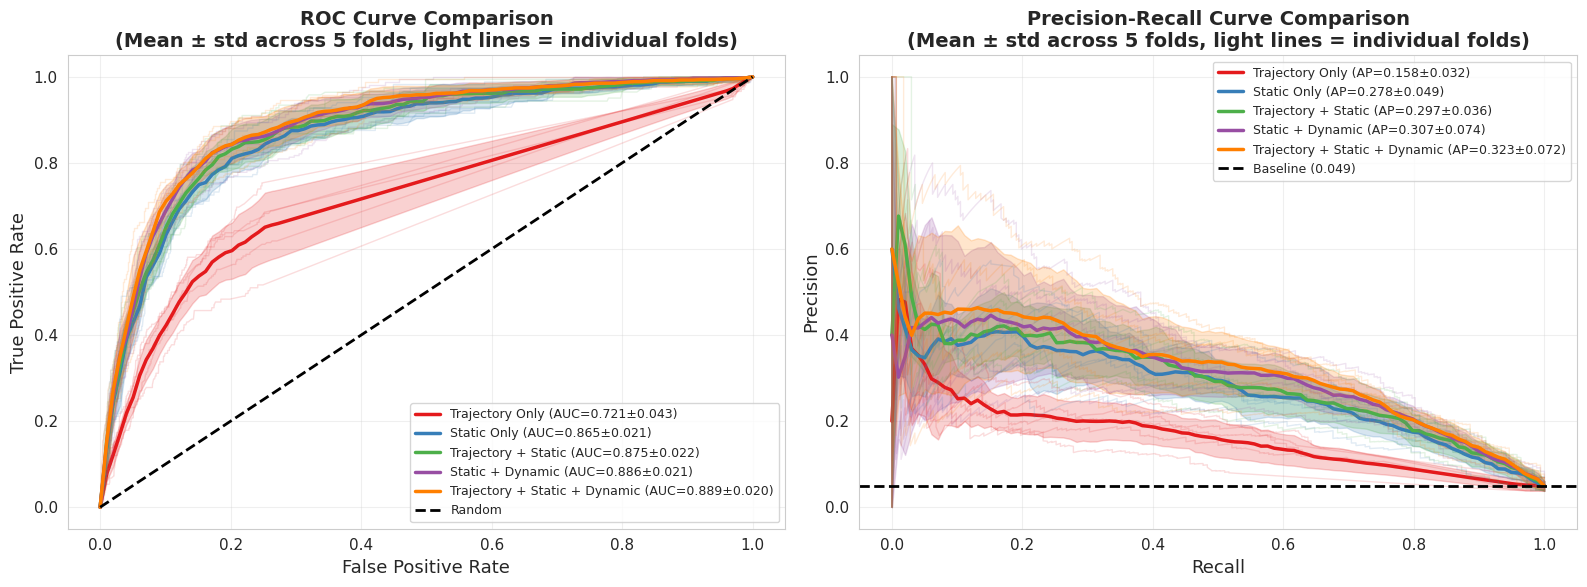

✓ Saved: results/mimic/feature_importance_combined.png


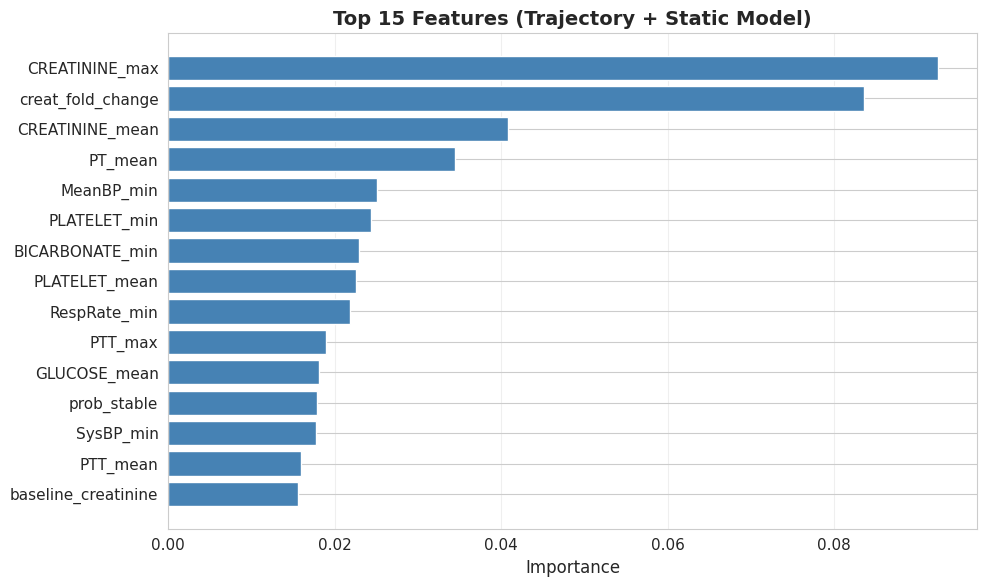

In [ ]:
# Performance comparison table
summary_df = pd.DataFrame([
    {
        'Model': name,
        'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'Avg Precision': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
    }
    for name, metrics in comparison_results.items()
])

print("\n1. Performance Summary:")
print(summary_df.to_string(index=False))

# ROC & PR Curves - Using shared utility function
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_aki_stage3',
    color_scheme='Set1'
)
plt.savefig('../../results/mimic/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/mimic/model_comparison_curves.png")
plt.show()


✓ Saved: results/mimic/model_comparison_boxplots.png


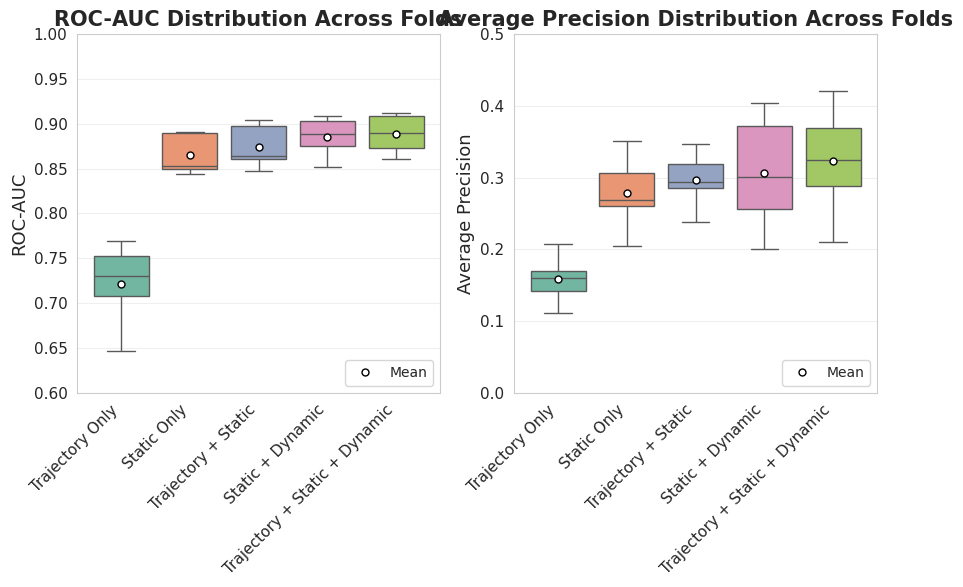


📊 Cross-Validation Stability Analysis:

   Trajectory Only:
      ROC-AUC std:          0.0427 (lower is more stable)
      Avg Precision std:    0.0316 (lower is more stable)

   Static Only:
      ROC-AUC std:          0.0206 (lower is more stable)
      Avg Precision std:    0.0488 (lower is more stable)

   Trajectory + Static:
      ROC-AUC std:          0.0222 (lower is more stable)
      Avg Precision std:    0.0361 (lower is more stable)

   Static + Dynamic:
      ROC-AUC std:          0.0206 (lower is more stable)
      Avg Precision std:    0.0743 (lower is more stable)

   Trajectory + Static + Dynamic:
      ROC-AUC std:          0.0198 (lower is more stable)
      Avg Precision std:    0.0717 (lower is more stable)


In [ ]:
# Boxplot visualization with statistical significance testing (using shared utilities)
# Define pairs to compare (indices based on feature_sets order)
pairs_to_compare = [
    (0, 1),  # Trajectory vs Static
    (1, 2),  # Static vs Traj+Static
    (2, 3),  # Traj+Static vs Static+Dynamic
    (3, 4),  # Static+Dynamic vs Traj+Static+Dynamic (Full)
]

# Use shared utility function for boxplots with significance testing
fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_aki_stage3',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total
)
plt.savefig('../../results/mimic/aki_model_comparison_boxplots_significance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/mimic/aki_model_comparison_boxplots_significance.png")
plt.show()

# Print detailed statistical comparisons using shared utility
print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairs_to_compare
)

In [42]:
# Risk stratification using OUT-OF-SAMPLE predictions from cross-validation
# Use the best model's CV predictions (not training set predictions)
best_model_name = 'Trajectory + Static + Dynamic'
best_metrics = comparison_results[best_model_name]

# Create dataframe with out-of-sample predictions from CV
risk_analysis_df = pd.DataFrame({
    'y_true': best_metrics['y_true'],
    'risk_score': best_metrics['y_proba']
})

# Add risk groups based on predicted probability
risk_analysis_df['risk_group'] = pd.cut(
    risk_analysis_df['risk_score'],
    bins=[0, 0.33, 0.67, 1.0],
    labels=['Low', 'Medium', 'High']
)

print("\n1. Risk Stratification (Out-of-Sample CV Predictions):")
for risk_group in ['Low', 'Medium', 'High']:
    subset = risk_analysis_df[risk_analysis_df['risk_group'] == risk_group]
    event_rate = subset['y_true'].mean()
    n = len(subset)
    n_events = subset['y_true'].sum()
    mean_prob = subset['risk_score'].mean()
    print(f"  {risk_group:10s}: {event_rate:.1%} actual AKI rate | Mean predicted prob: {mean_prob:.1%} | ({n_events}/{n} windows)")

# Trajectory type vs AKI risk (using full data for interpretation)
print("\n2. AKI Risk by Trajectory Type:")
prediction_clean['dominant_traj'] = prediction_clean[[
    'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
]].idxmax(axis=1).str.replace('prob_', '')

for traj in ['stable', 'gradual_increase', 'rapid_increase']:
    subset = prediction_clean[prediction_clean['dominant_traj'] == traj]
    if len(subset) > 0:
        risk = subset['target_aki_stage3'].mean()
        print(f"  {traj.replace('_', ' ').title():20s}: {risk:6.1%} ({subset['target_aki_stage3'].sum()}/{len(subset)} windows)")

# Time-dependent analysis
print("\n3. AKI Risk by Hospital Day:")
prediction_clean['hospital_day'] = prediction_clean['time_day'].astype(int)

for day in range(0, 7):
    subset = prediction_clean[prediction_clean['hospital_day'] == day]
    if len(subset) > 10:
        risk = subset['target_aki_stage3'].mean()
        print(f"  Day {day}: {risk:.1%} ({subset['target_aki_stage3'].sum()}/{len(subset)} windows)")

print("   Trajectory and time analyses use full dataset for descriptive purposes only.")


1. Risk Stratification (Out-of-Sample CV Predictions):
  Low       : 1.1% actual AKI rate | Mean predicted prob: 10.3% | (165/14907 windows)
  Medium    : 10.5% actual AKI rate | Mean predicted prob: 49.1% | (238/2264 windows)
  High      : 32.0% actual AKI rate | Mean predicted prob: 80.6% | (521/1630 windows)

2. AKI Risk by Trajectory Type:
  Stable              :   3.8% (670/17606 windows)
  Gradual Increase    :  33.3% (16/48 windows)
  Rapid Increase      :  20.7% (238/1147 windows)

3. AKI Risk by Hospital Day:
  Day 0: 8.7% (2/23 windows)
  Day 1: 11.8% (25/211 windows)
  Day 2: 6.2% (35/569 windows)
  Day 3: 5.0% (56/1121 windows)
  Day 4: 3.7% (55/1503 windows)
  Day 5: 3.8% (58/1538 windows)
  Day 6: 3.5% (47/1362 windows)
   Trajectory and time analyses use full dataset for descriptive purposes only.
